# Exploring Chemical Space
Explore some clustering and visualisation models and compare them for two different datasets:
- A subset of ChEMBL small molecule entries with a molecular weight between 200 and 500. Since the entire set of ChEMBL entries is quite substantial, 10k entries were selected by random sampling (`chembl_200-500_10k`)
- The result of the PubChem search for "antibiotics" (`pubchem_antibiotics`).

Note: The ChEMBL dataset may still take quite some processing time - depending on your PC. You can do a random sampling of e.g. 3k entries in order to reduce the computational effort.

Tasks:
1) Load and inspect the two datasets `ChEMBL_200-500_10k.csv`. Note that they are fundamentally different.
2) Perform basic data cleaning and be mindful of which data to dismiss (if any). Hint: Think about standardising column names (at least for the relevant ones)
3) Make sure that the SMILES strings are valid - implement a function to clean up the SMILES returning (in a new column or Series) the canonical SMILES if the input is valid, and return `None` if the SMILES in the original data is not valid (). Hint: The `Normalizer` in  rdkit might be quite useful (https://www.rdkit.org/docs/cppapi/classRDKit_1_1MolStandardize_1_1Normalizer.html)
4) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.
5) Run different clustering techniques, e.g. snippets provided for Butina and HDBSCAN. You can also try the scikit-learn models kmeans or dbscan.
6) Use the fingerprints to run UMAP and TSNE dimensionality reductions (snippets provided).
7) Plot the data in scatterplots, using the cluster labels as colour map.
8) Adjust some parameters of the clustering models and apply filters if needed (e.g. only visualise clusters of a size larger than 10) to reach some satisfactory result
9) Visualise a representative molecule (e.g. centroids or centers of clusters, or random :) ) of the three largest clusters for both methods using rdkit
10) Respond to the discussion points


Import dependencies and datasets

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.MolStandardize.rdMolStandardize import Normalizer
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import hdbscan
import umap
from sklearn.manifold import TSNE

In [2]:
df_chembl_full = pd.read_csv('chembl_200-500_10k.csv')
df_pubchem_full = pd.read_csv('pubchem_antibiotics.csv')

chembl = df_chembl_full[['SMILES', 'ChEMBL ID', 'Molecular Weight', 'AlogP', 'Polar Surface Area', 'HBA', 'HBD', '#Rotatable Bonds']].copy()
pubchem = df_pubchem_full[['Smiles', 'Compound_CID', 'Name', 'Molecular_Weight', 'XLogP',
                           'Polar_Area', 'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count'
                           ]].copy().rename(columns={'Smiles': 'SMILES'})

display(chembl.head())
display(pubchem.head())

# standardarise column names is usually a good practice. look for command in solutions

,SMILES,ChEMBL ID,Molecular Weight,AlogP,Polar Surface Area,HBA,HBD,#Rotatable Bonds
0,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,CHEMBL50524,361.47,1.96,84.66,7.0,2.0,8.0
1,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,CHEMBL1719619,339.35,2.33,110.62,7.0,2.0,3.0
2,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,CHEMBL1989505,417.54,6.02,92.93,5.0,3.0,4.0
3,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,CHEMBL1673052,487.61,4.12,77.07,8.0,1.0,5.0
4,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,CHEMBL3084770,426.56,3.58,70.84,6.0,1.0,4.0


,SMILES,Compound_CID,Name,Molecular_Weight,XLogP,Polar_Area,H-Bond_Donor_Count,H-Bond_Acceptor_Count,Rotatable_Bond_Count
0,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,16131155,Antibiotic A 47934,1313.4,0.7,459.0,15,22,3
1,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,6439108,Antibiotic S 632-B1,323.4,0.3,96.0,2,5,7
2,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,9690107,Antibiotic FK 089,412.4,0.0,212.0,3,11,7
3,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,125607,Antibiotic A447 C,1157.3,6.1,273.0,6,22,15
4,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,5487319,DOB-41 antibiotic,370.4,1.5,119.0,2,8,7


In [3]:
print(chembl.info())
print(chembl.isna().sum())
chembl.dropna(inplace=True)
chembl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SMILES              9993 non-null   object 
 1   ChEMBL ID           10000 non-null  object 
 2   Molecular Weight    10000 non-null  float64
 3   AlogP               9946 non-null   float64
 4   Polar Surface Area  9946 non-null   float64
 5   HBA                 9946 non-null   float64
 6   HBD                 9946 non-null   float64
 7   #Rotatable Bonds    9946 non-null   float64
dtypes: float64(6), object(2)
memory usage: 625.1+ KB
None
SMILES                 7
ChEMBL ID              0
Molecular Weight       0
AlogP                 54
Polar Surface Area    54
HBA                   54
HBD                   54
#Rotatable Bonds      54
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 9946 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-N

In [4]:
print(pubchem.info())
print(pubchem.isna().sum())
pubchem.dropna(inplace=True)
pubchem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2358 entries, 0 to 2357
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SMILES                 2358 non-null   object 
 1   Compound_CID           2358 non-null   int64  
 2   Name                   2358 non-null   object 
 3   Molecular_Weight       2358 non-null   float64
 4   XLogP                  1905 non-null   float64
 5   Polar_Area             2358 non-null   float64
 6   H-Bond_Donor_Count     2358 non-null   int64  
 7   H-Bond_Acceptor_Count  2358 non-null   int64  
 8   Rotatable_Bond_Count   2358 non-null   int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 165.9+ KB
None
SMILES                     0
Compound_CID               0
Name                       0
Molecular_Weight           0
XLogP                    453
Polar_Area                 0
H-Bond_Donor_Count         0
H-Bond_Acceptor_Count      0
Rotatable_Bond_Count 

Data cleaning

In [5]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [6]:
normalizer = Normalizer()

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            normalized_mol = normalizer.normalize(mol)
            return Chem.MolToSmiles(normalized_mol)
        else:
            return None
    except Exception:
        return None
    
chembl['canonical_smiles'] = chembl['SMILES'].apply(canonicalize_smiles)
pubchem['canonical_smiles'] = pubchem['SMILES'].apply(canonicalize_smiles)


In [7]:
chembl.dropna(subset=['canonical_smiles'], inplace=True)
pubchem.dropna(subset=['canonical_smiles'], inplace=True)

chembl.drop_duplicates(subset=['canonical_smiles'], inplace=True)
pubchem.drop_duplicates(subset=['canonical_smiles'], inplace=True)

print(chembl.info())
print(pubchem.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9946 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SMILES              9946 non-null   object 
 1   ChEMBL ID           9946 non-null   object 
 2   Molecular Weight    9946 non-null   float64
 3   AlogP               9946 non-null   float64
 4   Polar Surface Area  9946 non-null   float64
 5   HBA                 9946 non-null   float64
 6   HBD                 9946 non-null   float64
 7   #Rotatable Bonds    9946 non-null   float64
 8   canonical_smiles    9946 non-null   object 
dtypes: float64(6), object(3)
memory usage: 777.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 1905 entries, 0 to 2357
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SMILES                 1905 non-null   object 
 1   Compound_CID           1905 non-null  

Calculate Morgan Fingerprints (`GetMorganGenerator`). You can experiment with other fingerprints (`GetRDKitFPGenerator`) as well and see how they impact the clusters.

In [8]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

chembl['fp'] = chembl['canonical_smiles'].apply(
    lambda smi: mfpgen.GetFingerprint(Chem.MolFromSmiles(smi))
)
pubchem['fp'] = pubchem['canonical_smiles'].apply(
    lambda smi: mfpgen.GetFingerprint(Chem.MolFromSmiles(smi))
)

Butina Clustering: Investigate later how different cutoffs for the similarity affect the clusters.

In [9]:
# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!

def compute_distance(fp_list):
    dists = []
    nfps = len(fp_list)

    for i in range(1, nfps):
        similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
        dists.extend([1-x for x in similarities])

    # Apply Butina Clustering

    # Apply different thresholds later and see how they affect the clustering
    cutoff = 0.7  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

    butina_clusters = Butina.ClusterData(
        dists, # similarity based distance matrix
        nfps, # number of fingerprints
        cutoff,
        isDistData=True
    )

    print("Number of clusters:", len(butina_clusters))
    return butina_clusters

buttina_chembl = compute_distance(chembl['fp'].tolist())
buttina_pubchem = compute_distance(pubchem['fp'].tolist())

Number of clusters: 3499
Number of clusters: 377


In [10]:
def analyze_clusters(butina_clusters, nfps):    
    # filter out small clusters, rare chemoptypes, ...
    clusters_filtered = [c for c in butina_clusters if len(c) >= 10]

    butina_labels = np.full(nfps, -1)
    for cluster_id, cluster in enumerate(clusters_filtered):
        for id in cluster:
            butina_labels[id] = cluster_id

    sizes = [len(c) for c in clusters_filtered]

    print("clusters:", len(sizes))
    print("mean size:", np.mean(sizes))
    print("max size:", np.max(sizes))
    print("singletons:", sum(s == 1 for s in sizes))
    return butina_labels, sizes

print("Chembl Clusters:")
butina_labels_chembl, sizes_chembl = analyze_clusters(buttina_chembl, len(chembl))
print("\nPubChem Clusters:")
butina_labels_pubchem, sizes_pubchem = analyze_clusters(buttina_pubchem, len(pubchem))

Chembl Clusters:
clusters: 154
mean size: 24.214285714285715
max size: 173
singletons: 0

PubChem Clusters:
clusters: 38
mean size: 31.57894736842105
max size: 113
singletons: 0


HDBSCAN Clustering: Inspect how `min_cluster_size` and `min_samples` affect the clusters later on. This might depend quite a lot on the dataset (try 15 and 5 for the PubChem data, <10 and <5 for the ChEMBL)

In [11]:
# use HDBSCAN for clustering
hdbs_chembl = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=3,
    metric="jaccard"
)

hdbs_labels_chembl = hdbs_chembl.fit_predict(chembl['fp'].tolist())

hdbs_pubchem = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric="jaccard"
)

hdbs_labels_pubchem = hdbs_pubchem.fit_predict(pubchem['fp'].tolist())

In [12]:
print("chembl:")
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels_chembl)) - (1 if -1 in hdbs_labels_chembl else 0))
print("Noise points:", list(hdbs_labels_chembl).count(-1))

print("pubchem:")
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels_pubchem)) - (1 if -1 in hdbs_labels_pubchem else 0))
print("Noise points:", list(hdbs_labels_pubchem).count(-1))

chembl:
Number of DBSCAN clusters: 2
Noise points: 2116
pubchem:
Number of DBSCAN clusters: 27
Noise points: 876


Embeddings: TSNE and UMAP

In [13]:
# convert fingerprints to numpy
def to_numpy(fps):
    X = np.zeros((len(fps), 2048), dtype=int)
    for i, fp in enumerate(fps):
        DataStructs.ConvertToNumpyArray(fp, X[i])
    return X

X_chembl = to_numpy(chembl['fp'])
X_pubchem = to_numpy(pubchem['fp'])

In [14]:
# Dimensionality reduction by TSNE
umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)

umap_chembl = umap_model.fit_transform(X_chembl)
umap_pubchem = umap_model.fit_transform(X_pubchem)

/Users/mircodill/DSA104/venv3.9/lib/python3.9/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/mircodill/DSA104/venv3.9/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/mircodill/DSA104/venv3.9/lib/python3.9/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


In [15]:
# Dimensionality reduction by TSNE
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_chembl = tsne_model.fit_transform(X_chembl)
tsne_pubchem = tsne_model.fit_transform(X_pubchem)

Visualise the two clustering methods in the two embeddings (e.g. as subplot). Make sure to label the axes properly.

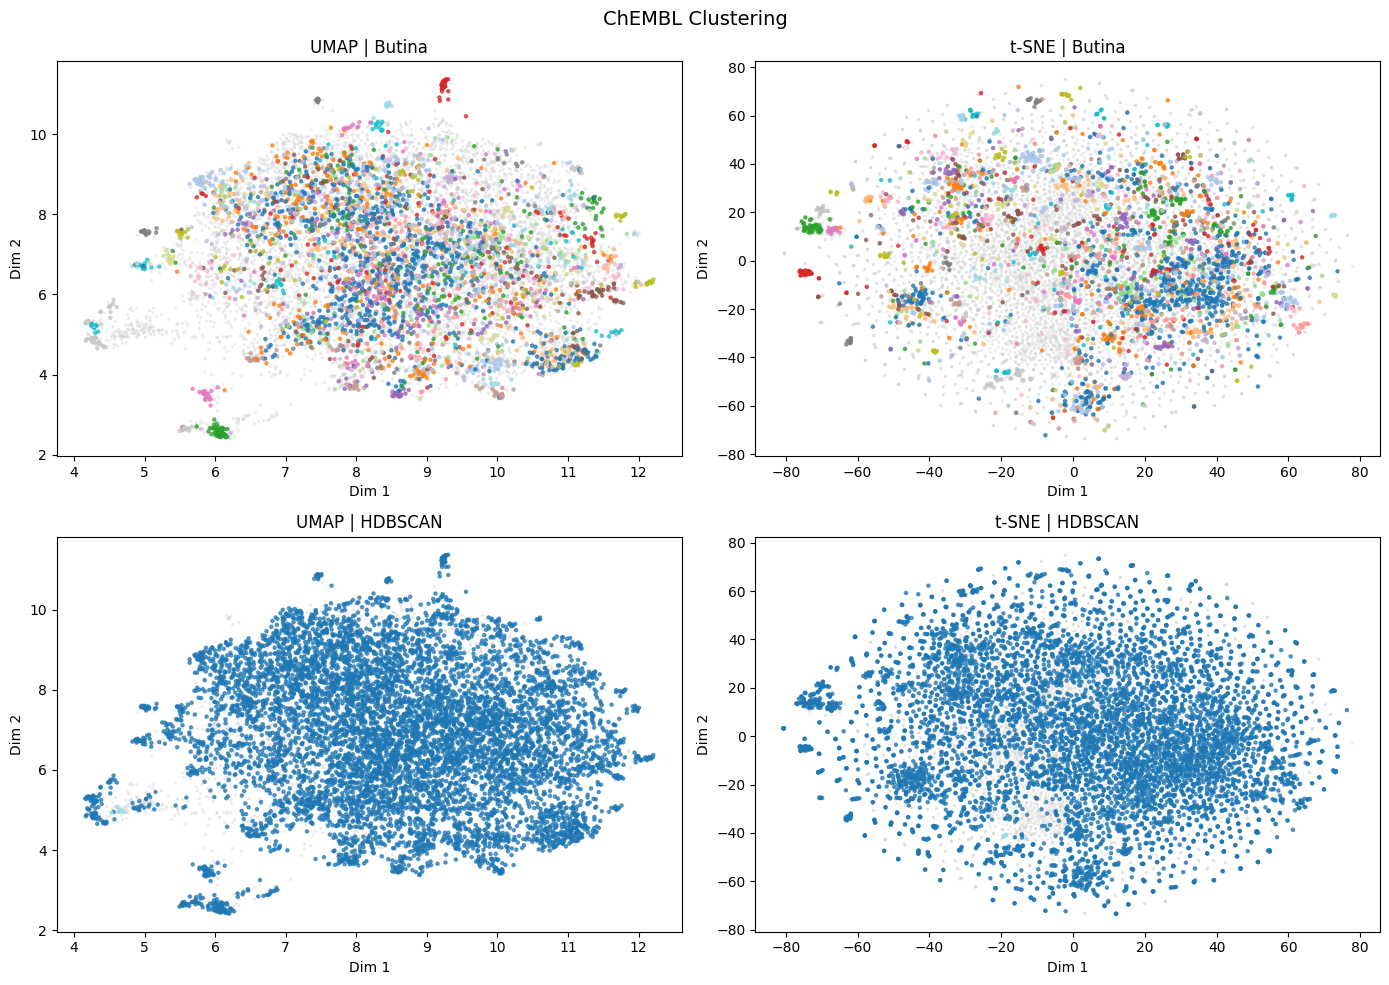

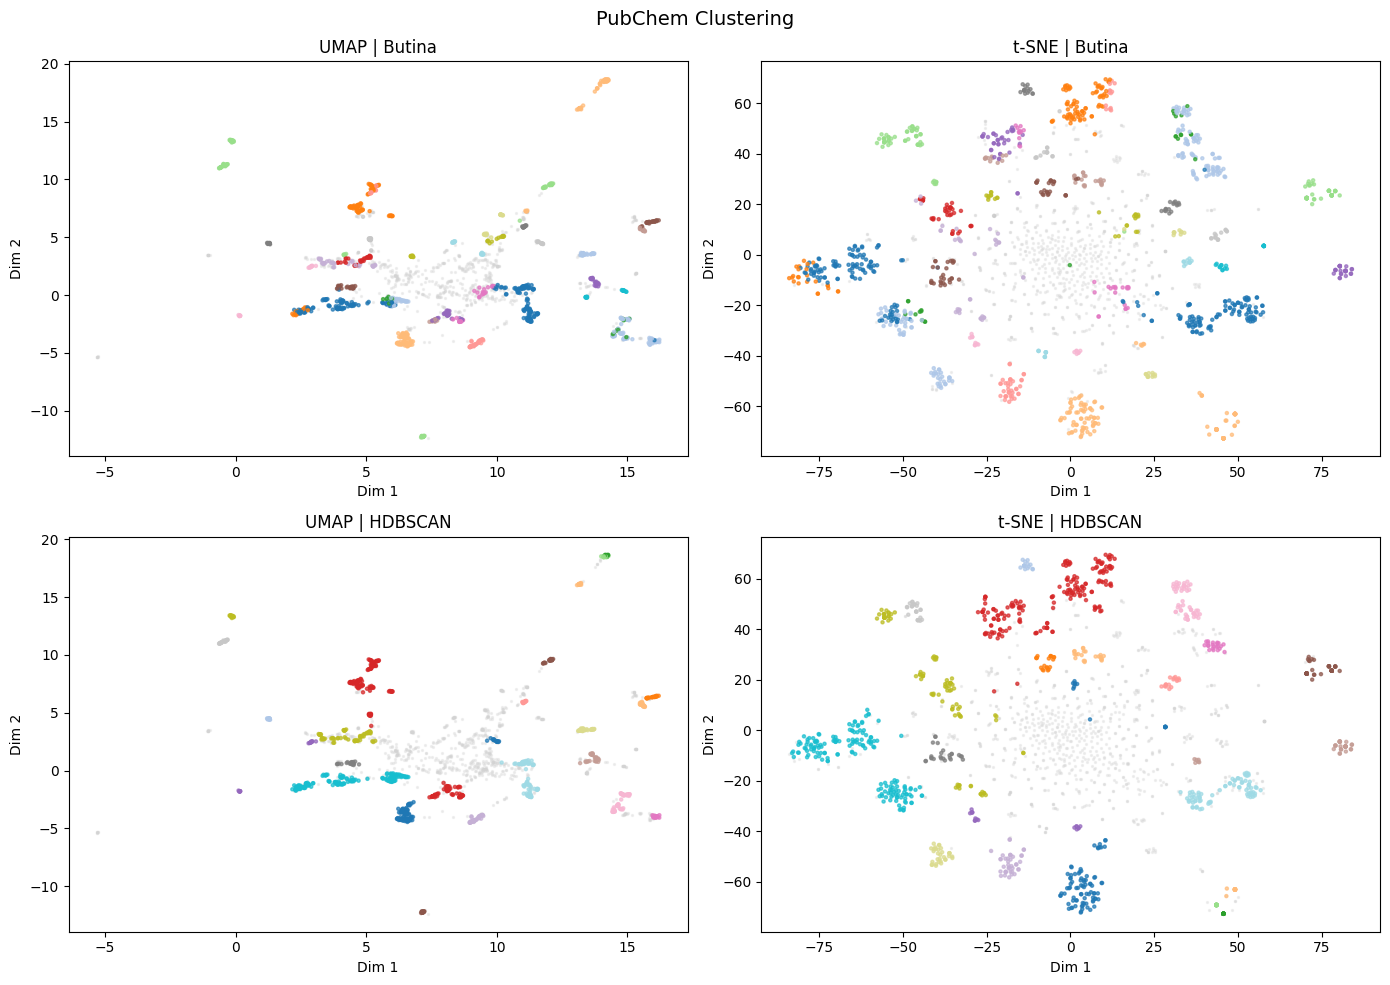

In [16]:
def plot_clusters(embedding, labels, title, ax, method):
    mask = labels >= 0  # Noise (-1) grau
    ax.scatter(*embedding[~mask].T, c='lightgrey', s=2, alpha=0.3, label='Noise')
    scatter = ax.scatter(*embedding[mask].T, c=labels[mask], cmap='tab20', s=5, alpha=0.7)
    ax.set_title(f"{method} | {title}")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("ChEMBL Clustering", fontsize=14)
plot_clusters(umap_chembl, butina_labels_chembl, "Butina", axes[0,0], "UMAP")
plot_clusters(tsne_chembl,  butina_labels_chembl, "Butina", axes[0,1], "t-SNE")
plot_clusters(umap_chembl, hdbs_labels_chembl,   "HDBSCAN", axes[1,0], "UMAP")
plot_clusters(tsne_chembl,  hdbs_labels_chembl,   "HDBSCAN", axes[1,1], "t-SNE")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("PubChem Clustering", fontsize=14)
plot_clusters(umap_pubchem, butina_labels_pubchem, "Butina", axes[0,0], "UMAP")
plot_clusters(tsne_pubchem,  butina_labels_pubchem, "Butina", axes[0,1], "t-SNE")
plot_clusters(umap_pubchem, hdbs_labels_pubchem,   "HDBSCAN", axes[1,0], "UMAP")
plot_clusters(tsne_pubchem,  hdbs_labels_pubchem,   "HDBSCAN", axes[1,1], "t-SNE")
plt.tight_layout()
plt.show()

Visualise representative molecules of the three biggest clusters of both methods.

Butina Clustering Representatives - ChEMBL:


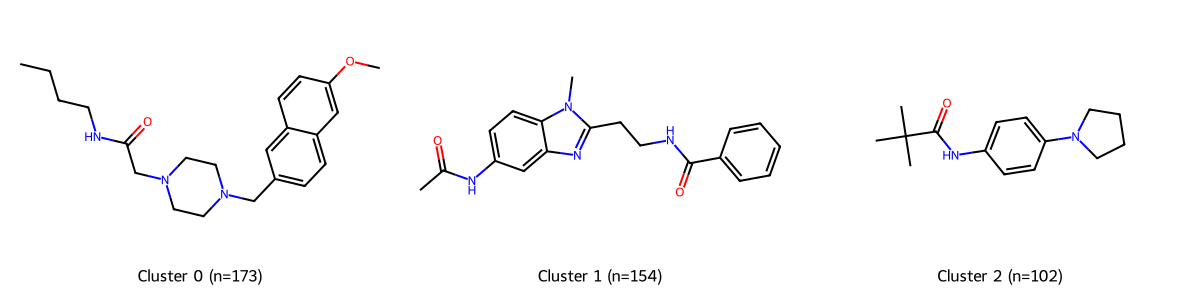

Butina Clustering Representatives - PubChem:


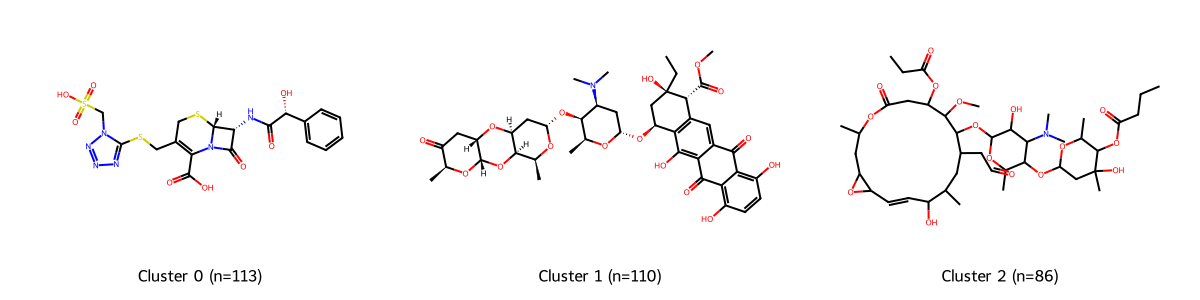

HDBSCAN Clustering Representatives - ChEMBL:


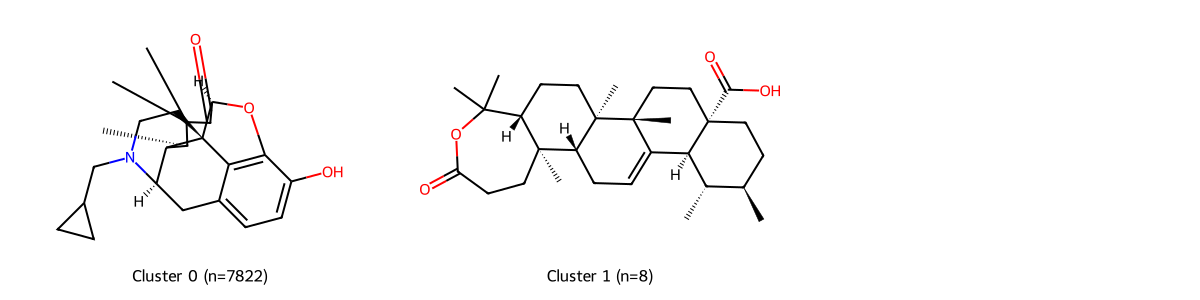

HDBSCAN Clustering Representatives - PubChem:


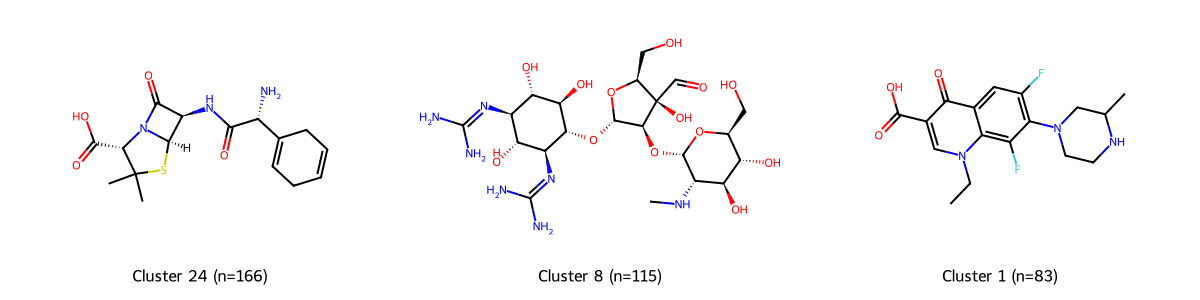

In [19]:
def show_representatives(df, labels, dataset_name, method_name):
    label_series = pd.Series(labels)
    # 3 grösste Cluster (ohne Noise=-1)
    top3 = label_series[label_series >= 0].value_counts().head(3).index.tolist()
    
    mols, legends = [], []
    for cluster_id in top3:
        idx = label_series[label_series == cluster_id].sample(1, random_state=42).index[0]
        smi = df.iloc[idx]['canonical_smiles']
        mol = Chem.MolFromSmiles(smi)
        size = (label_series == cluster_id).sum()
        mols.append(mol)
        legends.append(f"Cluster {cluster_id} (n={size})")
    
    img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(400, 300), legends=legends)
    display(img)

# Butina
print("Butina Clustering Representatives - ChEMBL:")
show_representatives(chembl, butina_labels_chembl, "chembl", "butina")
print("Butina Clustering Representatives - PubChem:")
show_representatives(pubchem, butina_labels_pubchem, "pubchem", "butina")

# HDBSCAN
print("HDBSCAN Clustering Representatives - ChEMBL:")
show_representatives(chembl, hdbs_labels_chembl, "chembl", "hdbscan")
print("HDBSCAN Clustering Representatives - PubChem:")
show_representatives(pubchem, hdbs_labels_pubchem, "pubchem", "hdbscan")

## Discussion points
1) What are the characteristics of the chemical spaces described in the two dataset? What is the difference?
2) How do density-based clustering techniques compare to models based on similarity in light of the differences in the datasets?
3) What were the best model parameters for the clustering techniques (i.e. that delivered a meaningful result)
4) Comment on the different dimensionality reduction techniques (again in light of the different dataset characteristics)
5) What was the best / most meaningful combination of dimensionality reduction and clustering methods?
6) Comment on some cheminformatics modelling challenges you may have encountered (e.g. runtime, singleton clusters, paramtersensitivity). What could be done to work around a large number of clusters of small size?
7) On the antibiotics dataset, can you identify some known antibiotic classes / motives in your clusters?


1. chembl is a selection of a chemically diverse spectrum, very heterogenous beside the mol weight of 200-500. pubchem is a selection based on the keyword antibiotics, so while molecules can be diverse, the function is what determines the selection.
2. The clustering with Buttina itself works fine and gives a reasonable amount of clusters, with the relatively high threshold. but independent of the dimensionality reduction, the clusters don't separate nicly for the chembl set. with the pubchem this looks much better. hdbscan does only return 2 cluster for chembl, so density in chemical space is too low for the set parameters. for the ubchem set the clustering works similar effective as buttina.
Density-base model struggle with sparse space, because there are not very highly conentrated spaces.
3. I had runtimes between 1 and 8 minutes to test settings, so i did not tune the parameters extensively. the butina threshold is quite high, to not obtain ane ven higher amount of clusters.
all methods are so heavily based on the set parameter. in unsupervised we take so many assumptions.
4. again the main difference is the data set. visibly from the plots they worked similarly bad for the chembl and similarly good for the pubchem data set. the t-sne visually groups nicely but has noise randomly spread around the center. both are applied in literature.
spacial proximita is not retained at all in t-sne, but retained a little in umap (dont overinterpret, but there is a distorted retention of space)
5. if I have to chose, butina with umap appears to give the tightest clusters.
6. i had very long runtimes up to 8 minutes especially for the hdbscan. still hdbscan with chembl only yielded two clusters. most clusters with butina were singletons, still when the threshold is high. min size for clusters is essential, but the noise is large.
Solutions: if we have enough data points, random sampling, split up data set. implement a similarity filter like in butina with the similarity measure. can be applied with other clustering techniques as well. feature engineering, get rid of features that only introduce noise.
problem with outlier removal (eg filtering small clusters): you may miss molecules from unexplored groups that are actually the solution to your problem.
7. I honestly don't know and recognize the antibiotic classes. Sulfonamides, beta-lactames, polyketides, tetracycline